Uitvoeren functie. Zie metadata_dataframe_function_test.py voor referentie

In [1]:

#running function
import pandas as pd
from metadata import metadata_dataframe as ms
#note: de invoer van paden met '/' ipv '\' en als string invoeren
df_raw = pd.DataFrame(data = ms("C:/Users/m.venema/Desktop/bestanden_root_dir", "C:/Users/m.venema/Desktop/metadata_script/logs"))

In [ ]:
from DataFrame_class_pipeline import DataFrame_pipeline
import dtale
object = DataFrame_pipeline(root_dir = "C:/Users/m.venema\Desktop/bestanden_root_dir",
                            log_folder_path = "C:/Users/m.venema/Desktop/pipeline_test/logging_folder",
                            xlsx_path = "C:/users/m.venema/Desktop/pipeline_test/xlsx_path")

print(object.output_options)
print(object.function_calls)
df = object.output_dataframe_dict["Image"](summary = True)
d = dtale.show(df)
d.open_browser()

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
C:\Users\m.venema\AppData\Local\Temp\ipykernel_28200\2798379214.py:3: SyntaxWarning: invalid escape sequence '\D'
  object = DataFrame_pipeline(root_dir = "C:/Users/m.venema\Desktop/bestanden_root_dir",
2026-05-18 14:02:54,680 - INFO     - found 202 json files


['basis', 'Coverage (non-NA) of metadata by filetype', 'Leftover fields', 'docx', 'msg', 'jpg', 'pdf', 'xlsx', 'Message ns', 'Mapi', 'dc', 'pdf', 'xmp', 'X-tika', 'meta', 'Extendend properties', 'MSIP', 'Exif', 'Image']
[<function DataFrame_pipeline.__init__.<locals>.<lambda> at 0x000002B6F3337F60>, <function DataFrame_pipeline.__init__.<locals>.<lambda> at 0x000002B6F3337EC0>, <function DataFrame_pipeline.__init__.<locals>.<lambda> at 0x000002B6F339A5C0>, <function DataFrame_pipeline.__init__.<locals>.<genexpr>.<lambda> at 0x000002B6F3399EE0>, <function DataFrame_pipeline.__init__.<locals>.<genexpr>.<lambda> at 0x000002B6F339A340>, <function DataFrame_pipeline.__init__.<locals>.<genexpr>.<lambda> at 0x000002B6F339A7A0>, <function DataFrame_pipeline.__init__.<locals>.<genexpr>.<lambda> at 0x000002B6F3399F80>, <function DataFrame_pipeline.__init__.<locals>.<genexpr>.<lambda> at 0x000002B6F339A520>, <function DataFrame_pipeline.__init__.<locals>.<genexpr>.<lambda> at 0x000002B6F339B380>,

Useful for copying long lists or other output to clipboard for manual inspection

In [ ]:
import pyperclip
import pandas as pd


2.3.3


1. Generating dataframes filtered on filetype (pdf, docx, msg, xlsx, jpg)
2. Generating dataframes filtered on specific metadata standard namespaces (dc, mapi, pdf, xmp etc)

Tip: use the Microsoft DataWrangler tool for visualising DataFrames in the notebook (or VScode)

In [2]:

#listing all unique file types in full dataframe
filetype_list = list(df_raw["tika:file_ext"].unique())

#functie voor het genereren van DataFrames op basis van bestandstype
def genereren_filetype_dfs(df_raw, filetype_list):
    filetype_dict = {}
    for regex_str in filetype_list:
       df = (df_raw
       .set_index("tika:file_ext")
       .filter(axis=0, regex=regex_str) #bestandstype (filetype list) wordt hier als regex string gebruikt om te filteren
       .dropna(axis=1, how="all") #alle kolommen (metadata velden) die geen waarde hebben verwijderen
       .reset_index())
       df_index = df.replace("", None).notna().sum(axis = 1).sort_values(ascending = False).index #sorteren op gevuldheid
       filetype_dict[regex_str] = df.reindex(df_index)   #.set_index("tika:file_ext")
    return filetype_dict

#initialiseren van (DataFrames)
filetype_dfs = genereren_filetype_dfs(df_raw, filetype_list)
df_pdf = filetype_dfs["pdf"]
df_docx = filetype_dfs["docx"]
df_msg = filetype_dfs["msg"]
df_jpg = filetype_dfs["jpg"]
df_xlsx = filetype_dfs["xlsx"]

#### generate 
#row: unique values
#column: unique values
#row: missing values
#column: missing values


#namespace dictionary
namespace_dict_names = {"Message": "Message:|Message-",
                "Mapi" : "mapi:",
                "dc" : "^dc:|dcterms",
                "pdf" : "^pdf:|pdfaid|pdfa:|pdfuaid",
                "xmp" : "^xmp:|xmpMM:|xmpTPg",
                "X-tika" :"X-TIKA:|tika|tika_|tika_batch",
                "meta" : "meta:",
                "extendend_properties" : "extended-properties:",
                "MSIP" : "^(?!pdf:).*MSIP_Label",
                "Exif": "Exif|exif"}

###DF columns!? dat moet ff anders

#functie voor het genereren van namespace DataFrames
def genereren_namespace_dfs(df_raw, namespace_dict_names):
    namespace_return = {}
    df_columns = [] #df_columns object is used later to create a separate image namespace dataframe (outside of function)
    for name, regex_str in namespace_dict_names.items():
        df = df_raw.filter(axis = 1, regex = regex_str).replace("", None).dropna(how = "all", axis = 0) #replacing empty strings so we can properly drop na values
        df = df[df.isna().sum().sort_values(ascending=True).index] #sorteren op basis van gevuldheid
        column = df_raw.loc[df.index, "tika:file_ext"] 
        df = pd.concat([df, column], axis = 1) #adding filetype column manually to index
        df = df.set_index("tika:file_ext") #indexing on file type
        df_columns.append(df.columns)
        namespace_return[name] = df
    return namespace_return, df_columns


#calling function
namespace_dfs, df_columns = genereren_namespace_dfs(df_raw, namespace_dict_names)
#DataFrame creation (Namespace DataFrames) using names and corresponding Regex strings from namespace dict
df_message_ns = namespace_dfs["Message"]
df_pdf_ns = namespace_dfs["pdf"]
df_Mapi_ns = namespace_dfs["Mapi"]
df_dc_ns = namespace_dfs["dc"]
df_xmp_ns = namespace_dfs["xmp"]
df_Xtika_ns = namespace_dfs["X-tika"]
df_meta_ns = namespace_dfs["meta"]
df_ExtendedProperties_ns = namespace_dfs["extendend_properties"]
df_MSIP_ns = namespace_dfs["MSIP"]
df_exif_ns = namespace_dfs["Exif"]

##making a separate image namespace DataFrame consisting of all fields that exist in .jpg files that do not exist in any other files (so all tika fields are also excluded)
###note: this code uses the df_columns object from generate_namespace_dfs() function
jpeg_only = df_raw.set_index("tika:file_ext").index.str.lower().str.match("jpg") #indexing on jpg files and generating bool mask of jpg files (true if jpg, false if other)
non_jpeg = ~jpeg_only #inverting the line above to select all non-jpg files
has_value_in_jpg = df_raw[jpeg_only].notna().any(axis=0) #what metadata fields have at least one non-na value in jpg files? (return True / False)
has_value_in_non_jpg = df_raw[non_jpeg].notna().any(axis=0) # what metadata fields have at least one non-na value in non-jpg files? (return True / False)
jpg_only_cols = has_value_in_jpg & ~has_value_in_non_jpg # Flip non-jpg booleans and compare!
df_image_namespace = df_raw.loc[:, jpg_only_cols].dropna(how = "all", axis = 0).drop(df_exif_ns.columns, axis = 1) #making dataframe and dropping exif columns
tika_column = df_raw.loc[df_image_namespace.index, "tika:file_ext"] #adding filetype column
df_image_namespace = pd.concat([df_image_namespace, tika_column], axis = 1).set_index("tika:file_ext") #indexing on filetype

#making a leftover DataFrame (all metadatafields that do not exist in a namespace)
###note: this code uses the df_columns object from generate_namespace_dfs() function
df_columns.append(df_image_namespace.columns) #this is why the df_columns object was required, so the fields from the image_namespace could be added manually
namespace_kolommen = pd.Index([]).append(df_columns) #making index
df_leftovers = df_raw.drop(namespace_kolommen, axis = 1).set_index("tika:file_ext") #dropping the index from the raw dataframe to create the leftovers!



Adding handy statistics for metadata fields to dataframes

In [3]:
from itertools import combinations, chain

#function for including some useful information about the prevalence of NA, non-NA and unique values of metadata fields.
def summary_columns(df : object):
    missing_values_percentage = (df.isna().sum() / len(df) * 100).round(1)
    missing_values_percentage = missing_values_percentage.astype(str) + "%" #adding a percent symbol manually
    columns =  pd.DataFrame({    #create summary stats for metadata
        "unique values" : df.astype(str).nunique(),
        "Non-NA values" : df.notna().sum(),
        "NA values" : df.isna().sum(),
        "NA values (%)" : missing_values_percentage
    })
    output = pd.concat([df, columns.T]) #merge summary columns with input dataframe
    output = pd.concat([output.iloc[-4:], output.iloc[:-4]]) #change position of the summary stats from last 4 to first 4
    return output

#creating df objects
summary_docx = summary_columns(df_docx)
summary_pdf = summary_columns(df_pdf)
summary_msg = summary_columns(df_msg)
summary_xlsx = summary_columns(df_xlsx)
summary_jpg = summary_columns(df_jpg)


#useful function for visualising metadata fields that contain duplicates!
##note: probably replace list with generator, may be really slow if applied to a large dataset
def visualiseren_duplicaten_DataFrames(df : object): #Takes df as input
    columns = []
    for col_a, col_b in combinations(df.columns, 2):
        overlap = (df[col_a] == df[col_b]).sum()
        percentage_overlap = overlap / len(df) * 100
        if percentage_overlap > 70: #conditional logic that applies the percentage of similarity between column a and b (can be set lower or higher)
            columns.append((col_a, col_b))
    unpack = list(chain.from_iterable(columns))
    remove_duplicates = list(dict.fromkeys(unpack))
    df = df[remove_duplicates]
    df = summary_columns(df)
    return df

#initialising dataframes from function
df_msg_dupes = visualiseren_duplicaten_DataFrames(df_msg)
df_pdf_dupes = visualiseren_duplicaten_DataFrames(df_pdf)
df_docx_dupes = visualiseren_duplicaten_DataFrames(df_docx)
df_jpg_dupes = visualiseren_duplicaten_DataFrames(df_jpg)
df_xlsx_dupes = visualiseren_duplicaten_DataFrames(df_xlsx)





In [55]:
a = df_raw.set_index("tika:file_ext").filter(axis = 0, regex = "docx")
b = a.notna().sum() / len(a) * 100

In [5]:
#percentages berekenen gevuldheid metadatavelden per bestandstype
#berekenen percentage metadataveld gevuld per bestandstype 


#making namespace series for all metadatafields 
def make_namespace_series(namespace_dfs, df_image_namespace, df_leftovers): #note dat deze functie de dictionary en image_namespace DataFrame van de vorige codecell als input gebruiken
    combined = []
    for name, df in namespace_dfs.items():
        series = pd.Series(name, index = df.columns)
        combined.append(series)
    combined.append(pd.Series("Image", index = df_image_namespace.columns)) #handmatig de image_namespace column
    combined.append(pd.Series("Restant", index = df_leftovers.columns)) #handmatig de restant columns
    combined = pd.concat(combined)
    return combined

a = make_namespace_series(namespace_dfs, df_image_namespace, df_leftovers)

#percentages berekenen gevuldheid metadatavelden per bestandstype
#berekenen percentage metadataveld gevuld per bestandstype 
def berekenen_percentages(df_raw, namespace_dfs, df_image_namespace, df_leftovers):
    filetype_list = list(df_raw["tika:file_ext"].unique())
    percentage_dict = {}
    for filetype in filetype_list:
        filter = df_raw.set_index("tika:file_ext").filter(axis = 0, regex = filetype)
        percentage = filter.notna().sum() / len(filter) * 100
        percentage_dict[filetype] = percentage
    df = pd.DataFrame(percentage_dict)
    df = df.round(1)
    df_mean_values = df.mean(axis = 1).round(1)
    df = pd.concat([df, df_mean_values], axis=1).rename({0 : 'gemiddelde'}, axis = 1).sort_values(axis = 0, by = ['gemiddelde'] , ascending= False)
    namespace_series = make_namespace_series(namespace_dfs, df_image_namespace, df_leftovers)
    df = df.assign(namespace = namespace_series)
    return df

df_percentage = berekenen_percentages(df_raw, namespace_dfs, df_image_namespace, df_leftovers)





Relative distribution of namespaces in all tested file types

Text(0.5, 1.0, 'relative distribution of metadata namespaces in all filetypes?')

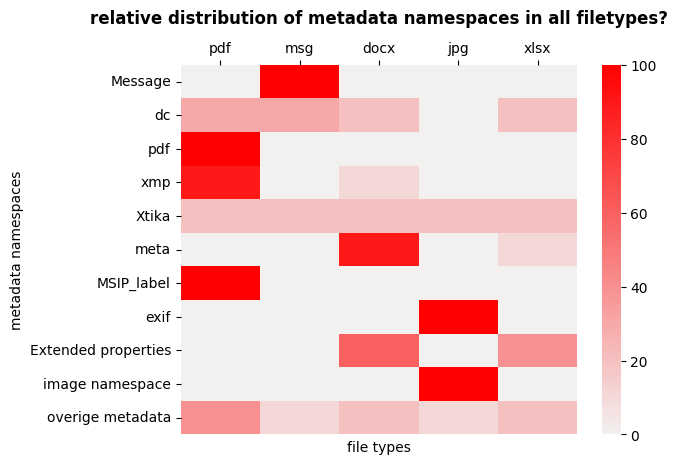

In [ ]:
import seaborn as sns

##L
dict_namespaces = {"Message": df_message_ns, 
                    "dc": df_dc_ns, 
                    "pdf" : df_pdf_ns,
                    "xmp" : df_xmp_ns,
                    "Xtika" : df_Xtika_ns,
                    "meta" : df_meta_ns,
                    "MSIP_label": df_MSIP_ns,
                    "exif" : df_exif_ns,
                    "Extended properties" : df_ExtendedProperties_ns,
                    "image namespace": df_image_namespace,
                    "overige metadata" : df_leftovers}

#telt alle non-NA waarden per bestandstype en telt ze bij elkaar op
#dit doe je voor alle bestandsformaten, dus je returned 3 waarden per namespace df 
def tellen_waarden(df):
    return {
        "pdf":   df.filter(axis=0, regex="pdf").count().sum() / len(df_pdf.index), 
        "msg": df.filter(axis=0, regex="msg").count().sum() / len(df_msg.index), 
        "docx":  df.filter(axis=0, regex="docx").count().sum() / len(df_docx.index), 
        "jpg": df.filter(axis=0, regex = "jpg").count().sum() / len(df_jpg.index), 
        "xlsx": df.filter(axis=0, regex = "xlsx").count().sum() / len(df_xlsx.index)
    }
    
    
# binnen bestandsformaten distributie uitzetten namespaces 
# per pdf , %namespace

#a = df_xmp_namespace.filter(axis=0, regex="\.pdf$").count(axis=1).sum()
#gebruikt dict_namespaces, kolomnaam eerste item + namespace_df als parameter voor tellen_waarden functie
df_counts = pd.DataFrame(
    {name: tellen_waarden(df) for name, df in dict_namespaces.items()})

# Totale waarde / waarde bestandsformaat * 100 
##relatieve distributie van namespaces binnen bepaalde bestandsformaten
df_distributie = df_counts.div(df_counts.sum(axis=0), axis=1).round(1) * 100

color_palette = sns.color_palette("light:r", as_cmap=True)
heatmap = sns.heatmap(df_distributie.T, cmap = color_palette)
heatmap.xaxis.tick_top()
heatmap.set_ylabel("metadata namespaces")
heatmap.set_xlabel("file types")
heatmap.set_title("relative distribution of metadata namespaces in all filetypes?", pad = 30, fontweight="bold")


In [ ]:

ai_classification_cols = [
    # Identity & threading
    'Message:Raw-Header:Message-ID',
    'Message:Raw-Header:Thread-Index',
    'Message:Raw-Header:Thread-Topic',
    'Message:Raw-Header:In-Reply-To',
    'Message:Raw-Header:References',
    # Attachment signals
    'Message:Raw-Header:X-MS-Has-Attach',
    'Message:Raw-Header:Content-Disposition',
    'Message:Raw-Header:Content-Transfer-Encoding',
    'Message:Raw-Header:Content-Type',
    # People
    'Message-From', 'Message:From-Email', 'Message:From-Name',
    'Message-To', 'Message:To-Email', 'Message:To-Display-Name',
    'Message-Cc', 'Message:CC-Email',
    # Content signals
    'Message:Raw-Header:Subject',
    'Message:Raw-Header:Date',
    'Message:Raw-Header:Content-Language',
    'Message:Raw-Header:Importance',
    'Message:Raw-Header:X-Priority',
    'Message:Raw-Header:X-Mailer',
    'Message:Raw-Header:Precedence',
    'Message:Raw-Header:List-Id',
    'Message:Raw-Header:X-OriginatorOrg',
    'Message:Raw-Header:Reply-To',
]

ai_excluded_cols = [
    'Message-Recipient-Address',
    'Message:CC-Display-Name',
    'Message:CC-Name',
    'Message:Raw-Header:ARC-Authentication-Results',
    'Message:Raw-Header:ARC-Message-Signature',
    'Message:Raw-Header:ARC-Seal',
    'Message:Raw-Header:Accept-Language',
    'Message:Raw-Header:Authentication-Results',
    'Message:Raw-Header:Authentication-Results-Original',
    'Message:Raw-Header:CC',
    'Message:Raw-Header:CFBL-Address',
    'Message:Raw-Header:Cc',
    'Message:Raw-Header:Content-Class',
    'Message:Raw-Header:DKIM-Filter',
    'Message:Raw-Header:DKIM-Signature',
    'Message:Raw-Header:Deferred-Delivery',
    'Message:Raw-Header:Feedback-ID',
    'Message:Raw-Header:From',
    'Message:Raw-Header:IronPort-Data',
    'Message:Raw-Header:IronPort-HdrOrdr',
    'Message:Raw-Header:List-ID',
    'Message:Raw-Header:List-Unsubscribe',
    'Message:Raw-Header:List-Unsubscribe-Post',
    'Message:Raw-Header:MIME-Version',
    'Message:Raw-Header:Message-Id',
    'Message:Raw-Header:Mime-Version',
    'Message:Raw-Header:Received',
    'Message:Raw-Header:Received-SPF',
    'Message:Raw-Header:Return-Path',
    'Message:Raw-Header:To',
    'Message:Raw-Header:X-Accounttype',
    'Message:Raw-Header:X-AuditID',
    'Message:Raw-Header:X-Authenticated-Id',
    'Message:Raw-Header:X-Auto-Response-Suppress',
    'Message:Raw-Header:X-Brightmail-Tracker',
    'Message:Raw-Header:X-CSA-Complaints',
    'Message:Raw-Header:X-CSE-ConnectionGUID',
    'Message:Raw-Header:X-CSE-MsgGUID',
    'Message:Raw-Header:X-Campaign',
    'Message:Raw-Header:X-Campaign-ID',
    'Message:Raw-Header:X-ClamSpam',
    'Message:Raw-Header:X-CobytesB.V.-Domain',
    'Message:Raw-Header:X-CobytesB.V.-Outgoing-Class',
    'Message:Raw-Header:X-CobytesB.V.-Outgoing-Evidence',
    'Message:Raw-Header:X-CobytesB.V.-Username',
    'Message:Raw-Header:X-Complaints-To',
    'Message:Raw-Header:X-CrossPremisesHeadersFiltered',
    'Message:Raw-Header:X-CrossPremisesHeadersPromoted',
    'Message:Raw-Header:X-Csa-Complaints',
    'Message:Raw-Header:X-EOPAttributedMessage',
    'Message:Raw-Header:X-EOPTenantAttributedMessage',
    'Message:Raw-Header:X-Entity-ID',
    'Message:Raw-Header:X-ExclaimerHostedSignatures-MessageProcessed',
    'Message:Raw-Header:X-ExclaimerImprintAction',
    'Message:Raw-Header:X-ExclaimerImprintLatency',
    'Message:Raw-Header:X-ExclaimerProxyLatency',
    'Message:Raw-Header:X-Feedback-ID',
    'Message:Raw-Header:X-Filter-ID',
    'Message:Raw-Header:X-Forefront-Antispam-Report',
    'Message:Raw-Header:X-Forefront-Antispam-Report-Untrusted',
    'Message:Raw-Header:X-Gm-Gg',
    'Message:Raw-Header:X-Gm-Message-State',
    'Message:Raw-Header:X-Google-DKIM-Signature',
    'Message:Raw-Header:X-Google-Smtp-Source',
    'Message:Raw-Header:X-Harmonics-Client',
    'Message:Raw-Header:X-IPAS-Result',
    'Message:Raw-Header:X-MC-User',
    'Message:Raw-Header:X-MS-Exchange-AntiSpam-MessageData-0',
    'Message:Raw-Header:X-MS-Exchange-AntiSpam-MessageData-ChunkCount',
    'Message:Raw-Header:X-MS-Exchange-AntiSpam-MessageData-Original-0',
    'Message:Raw-Header:X-MS-Exchange-AntiSpam-MessageData-Original-ChunkCount',
    'Message:Raw-Header:X-MS-Exchange-AntiSpam-Relay',
    'Message:Raw-Header:X-MS-Exchange-AtpMessageProperties',
    'Message:Raw-Header:X-MS-Exchange-Authentication-Results',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-AuthAs',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-AuthSource',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-FromEntityHeader',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-Id',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-MailboxType',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-Network-Message-Id',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-OriginalArrivalTime',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-OriginalAttributedTenantConnectingIp',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-UserPrincipalName',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-fromentityheader',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-id',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-mailboxtype',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-originalarrivaltime',
    'Message:Raw-Header:X-MS-Exchange-CrossTenant-userprincipalname',
    'Message:Raw-Header:X-MS-Exchange-ExternalInOutlookResult',
    'Message:Raw-Header:X-MS-Exchange-MessageSentRepresentingType',
    'Message:Raw-Header:X-MS-Exchange-Organization-AVStamp-Enterprise',
    'Message:Raw-Header:X-MS-Exchange-Organization-AuthAs',
    'Message:Raw-Header:X-MS-Exchange-Organization-AuthMechanism',
    'Message:Raw-Header:X-MS-Exchange-Organization-AuthSource',
    'Message:Raw-Header:X-MS-Exchange-Organization-ExpirationInterval',
    'Message:Raw-Header:X-MS-Exchange-Organization-ExpirationIntervalReason',
    'Message:Raw-Header:X-MS-Exchange-Organization-ExpirationStartTime',
    'Message:Raw-Header:X-MS-Exchange-Organization-ExpirationStartTimeReason',
    'Message:Raw-Header:X-MS-Exchange-Organization-MessageDirectionality',
    'Message:Raw-Header:X-MS-Exchange-Organization-Network-Message-Id',
    'Message:Raw-Header:X-MS-Exchange-Organization-SCL',
    'Message:Raw-Header:X-MS-Exchange-Processed-By-BccFoldering',
    'Message:Raw-Header:X-MS-Exchange-SenderADCheck',
    'Message:Raw-Header:X-MS-Exchange-SharedMailbox-RoutingAgent-Processed',
    'Message:Raw-Header:X-MS-Exchange-Transport-CrossTenantHeadersPromoted',
    'Message:Raw-Header:X-MS-Exchange-Transport-CrossTenantHeadersStamped',
    'Message:Raw-Header:X-MS-Exchange-Transport-CrossTenantHeadersStripped',
    'Message:Raw-Header:X-MS-Exchange-Transport-EndToEndLatency',
    'Message:Raw-Header:X-MS-Iris-MetaData',
    'Message:Raw-Header:X-MS-Office365-Filtering-Correlation-Id',
    'Message:Raw-Header:X-MS-Office365-Filtering-Correlation-Id-Prvs',
    'Message:Raw-Header:X-MS-PublicTrafficType',
    'Message:Raw-Header:X-MS-TNEF-Correlator',
    'Message:Raw-Header:X-MS-TrafficTypeDiagnostic',
    'Message:Raw-Header:X-MailCleaner',
    'Message:Raw-Header:X-MailCleaner-Forced',
    'Message:Raw-Header:X-MailCleaner-ID',
    'Message:Raw-Header:X-MailCleaner-Information',
    'Message:Raw-Header:X-MailCleaner-ReportURL',
    'Message:Raw-Header:X-MailCleaner-SPF',
    'Message:Raw-Header:X-MailCleaner-SpamCheck',
    'Message:Raw-Header:X-MailCleaner-TLS-Client-Certificate',
    'Message:Raw-Header:X-MailCleaner-recipients',
    'Message:Raw-Header:X-MailCleaner-return_path',
    'Message:Raw-Header:X-MailCleaner-sender_address',
    'Message:Raw-Header:X-Mailin-Campaign',
    'Message:Raw-Header:X-Mailin-Client',
    'Message:Raw-Header:X-Message-ID',
    'Message:Raw-Header:X-Microsoft-Antispam',
    'Message:Raw-Header:X-Microsoft-Antispam-Mailbox-Delivery',
    'Message:Raw-Header:X-Microsoft-Antispam-Message-Info',
    'Message:Raw-Header:X-Microsoft-Antispam-Message-Info-Original',
    'Message:Raw-Header:X-Microsoft-Antispam-Untrusted',
    'Message:Raw-Header:X-NiceBayes',
    'Message:Raw-Header:X-OrganizationHeadersPreserved',
    'Message:Raw-Header:X-Originating-IP',
    'Message:Raw-Header:X-Received',
    'Message:Raw-Header:X-Recommended-Action',
    'Message:Raw-Header:X-Relaying-Domain',
    'Message:Raw-Header:X-Report-Abuse',
    'Message:Raw-Header:X-Report-Abuse-To',
    'Message:Raw-Header:X-SES-Outgoing',
    'Message:Raw-Header:X-SG-EID',
    'Message:Raw-Header:X-SG-ID',
    'Message:Raw-Header:X-SpamExperts-Domain',
    'Message:Raw-Header:X-SpamExperts-Outgoing-Class',
    'Message:Raw-Header:X-SpamExperts-Outgoing-Evidence',
    'Message:Raw-Header:X-SpamExperts-Username',
    'Message:Raw-Header:X-Spamc',
    'Message:Raw-Header:X-Talos-CUID',
    'Message:Raw-Header:X-Talos-MUID',
    'Message:Raw-Header:X-TsbHttpDeliveryResponseType',
    'Message:Raw-Header:X-UriRBLs',
    'Message:Raw-Header:X-VSS-Event-Initiator',
    'Message:Raw-Header:X-VSS-Event-Initiator-Ascii',
    'Message:Raw-Header:X-VSS-Event-Trigger',
    'Message:Raw-Header:X-VSS-Event-Type',
    'Message:Raw-Header:X-VSS-Scope',
    'Message:Raw-Header:X-VSS-Subscription-ID',
    'Message:Raw-Header:X-campaignid',
    'Message:Raw-Header:X-sib-id',
    'Message:Raw-Header:authentication-results',
    'Message:Raw-Header:client-request-id',
    'Message:Raw-Header:msip_labels',
    'Message:Raw-Header:request-id',
    'Message:Raw-Header:x-codetwo-clientsignature-inserted',
    'Message:Raw-Header:x-codetwoprocessed',
    'Message:Raw-Header:x-copernica-mid',
    'Message:Raw-Header:x-forefront-antispam-report',
    'Message:Raw-Header:x-ld-processed',
    'Message:Raw-Header:x-microsoft-antispam',
    'Message:Raw-Header:x-microsoft-antispam-message-info',
    'Message:Raw-Header:x-ms-exchange-antispam-messagedata-0',
    'Message:Raw-Header:x-ms-exchange-antispam-messagedata-chunkcount',
    'Message:Raw-Header:x-ms-exchange-antispam-relay',
    'Message:Raw-Header:x-ms-exchange-atpmessageproperties',
    'Message:Raw-Header:x-ms-exchange-calendar-series-instance-id',
    'Message:Raw-Header:x-ms-exchange-messagesentrepresentingtype',
    'Message:Raw-Header:x-ms-exchange-senderadcheck',
    'Message:Raw-Header:x-ms-exchange-sharedmailbox-routingagent-processed',
    'Message:Raw-Header:x-ms-office365-filtering-correlation-id',
    'Message:Raw-Header:x-ms-publictraffictype',
    'Message:Raw-Header:x-ms-reactions',
    'Message:Raw-Header:x-ms-traffictypediagnostic',
    'Message:Raw-Header:x-originating-ip',
    'Message:Raw-Header:x-trendmicro-cas-out-loop-identifier',
    'Message:Raw-Header:x-xink-handled',
    'Message:Raw-Header:x-zivver-dlp',
    'Message:Raw-Header:x-zivver-messageid',
    'Message:To-Name',
]

##message exclusie DataFrame ter visualisatie
message_exclusie = df_message_ns[ai_excluded_cols] 
#message_exclusie = message_exclusie[message_exclusie.notna().sum(axis = 0).sort_values(ascending= False).index]
#handmatig lijst uitbreiden
lijst_uitbreiden = list(message_exclusie.columns[:13]) #eerste 14 resultaten vanwege gevuldheid (100%)
#handmatig velden toevoegen op basis van procesinformatie (namen, adressen etc) of structuur (titels, language etc)
lijst_uitbreiden += ["Message:CC-Display-Name"] #Bevat namen
lijst_uitbreiden += ["Message:Raw-Header:CC"] #Bevat namen
lijst_uitbreiden += ["Message:Raw-Header:X-VSS-Event-Initiator-Ascii"] # Bevat namen
lijst_uitbreiden += ["Message:Raw-Header:Return-Path"] 
lijst_uitbreiden += ["Message:Raw-Header:To"]
lijst_uitbreiden += ["tika:file_ext"]
duplicate_check = [x for x in lijst_uitbreiden if x not in ai_classification_cols] #voorkomen van duplicaten
revised_list = ai_classification_cols + duplicate_check #toevoegen metadatavelden aan selectie voorgesteld door Claude
#DataFrame voor selectie metadata velden .msg bestanden
message_selectie = df_message_ns.reset_index()[revised_list] 
message_index_sorted = message_selectie.notna().sum(axis = 0).sort_values(ascending = False).index
message_selectie = message_selectie[message_index_sorted]

In [40]:
#CELL B
#gelijk voor alle formaten (veelal gevulde velden in alle bestandsformaten) met 100% of bijna 100% gevuldheid
## Process = personen, emails, tijden
process_algemeen = ["resourceName", "tika_batch_fs:relative_path"]
##Structureel = titel, pagina, elementen, denk document structure/file etc
structureel_algemeen = ["Content-Type", "Content-Length"]
#proces per bestandstype (specifieke velden die alleen bij bepaalde formaten voorkomen)
process_docx = ["cp:revision", 
                "extended-properties:Company", 
                "dcterms:created",
                "dcterms:modified",
                "dc:publisher",
                "resourceName",
                "dc:creator",
                "meta:last-author",
                #"meta:print-date"  #nietszeggend veld?
]
process_pdf = ["dcterms:created", #pdf:docinfo:created en xmp:CreateDate,
               "dcterms:modified", #pdf:docinfo:modified
               "dc:title",#note: bij anonimisatie is de titel ook nietszeggend. Zelde als: pdf:docinfo:title, xmp:dc:title
               "dc:creator", #pdf:docinfo:creator, xmp:dc:creator
               "xmp:MetadataDate", #xmp:dc:description, pdf:docinfo:subject
               "dc:description", #niet veel gevuld
               "dc:subject", #niet veel gevuld
            ]
process_msg = [#standaard geskipped: server communicatie, ID's, MIME-type en indexes
               "Message:From-Email",
               "Message-From",
               "Message:To-Name",
               "Message:Raw-Header:Date",
               "Message:Raw-Header:Subject",
               "Message-Cc",
               "Message:To-Display-Name",
               "Message:To-Email",
               "Message-To",
               "Message:From-Name",
               "Message:Raw-Header:To",
               "Message:Raw-Header:Return-Path",
               "Message:Raw-Header:From",
               "Message-Recipient-Address",
               "Message:Raw-Header:Thread-Topic",
               "Message:Raw-Header:Reply-To",
               "Message:CC-Display-Name",
               "Message:Raw-Header:CC"
]


#structureel per bestandstype (specifieke velden die alleen bij bepaalde formaten voorkomen)
structureel_docx = ["meta:paragraph-count",
                    "meta:word-count", 
                    "meta:character-count-with-spaces",
                    "meta:line-count",
                    "meta:character-count",
                    "Content-Length",
                    "extended-properties:Application",
                    "xmpTPg:NPages",
                    "extended-properties:Template",
                    #"extended-properties:DocSecurityString",
                    #"X-TIKA:content",  #bevat een soort samenvatting van alle structurele metadata?
                    #"X-TIKA:embedded_depth",  #overgeslaten, bevat alleen nullen in testset
                    "meta:page-count",
                    #"extended-properties:TotalTime", #nietszeggend veld
                    #"extended-properties:DocSecurity",   #niet belangrijk
                    "dc:title", #note: laag voorkomen
                    #"custom:cs_objectid", #laag voorkomen en nietszeggend nummer
                    #"custom:ContentTypeId" #laag voorkomen en nietszeggend nummer
                    #"meta:keyword" #laag voorkomen
]
                    
structureel_pdf = [#standaard omitted: alle acces_permission en encryptie velden, alle IDs
    "xmpTPg:NPages", 
                   #"X-TIKA:content" #lijkt een soort summary te zijn
                   "pdf:containsNonEmbeddedFont",
                   "pdf:PDFVersion",
                   #"pdf:hasCollection" #alleen false values in testset,
                   "dc:format", #wellicht hetzelfde als pdf:PDFVersion
                   #"pdf:num3DAnnotations", #allemaal 0
                   #"pdf:hasXMP",  #nutteloos
                   #"pdf:unmappedUnicodeCharsPerPage", #allemaal 0
                   #"pdf:overallPercentageUnmappedUnicodeChars", #allemaal 0
                   #"pdf:containsDamagedFont", ?
                   "pdf:ocrPageCount",
                   "pdf:hasMarkedContent",
                   #"pdf:totalUnmappedUnicodeChars", #zegt niks
                   "pdf:charsPerPage",
                   #"pdf:docinfo:producer", #soms pdf appliciatie, soms word, soms anonimisatie software. Teveel ruis.
                   "pdf:producer", #pdf:docinfo:creator_tool, xmp:CreatorTool, xmp:pdf:Producer
                   "dc:language",
                   
]
structureel_msg = ["Message:Raw-Header:X-MS-Has-Attach", 
                   "Message:Raw-Header:Content-Language"
]

#velden die niet zijn meegenomen (alleen beschreven voor .pdf vanwege het aantal)
niet_meegenomen_pdf = ['pdf:docinfo:trapped', 
                       'xmpMM:History:Action', 
                       'xmpMM:History:SoftwareAgent', 
                       'xmpMM:History:InstanceID', 
                       'xmpMM:History:When', 
                       'MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_Method',
                       'pdf:docinfo:custom:MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_Name',
                       'pdf:docinfo:custom:MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_Tag',
                       'pdf:docinfo:custom:MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_ContentBits',
                       'pdf:docinfo:custom:MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_Method',
                       'pdf:docinfo:custom:MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_SetDate',
                       'pdf:docinfo:custom:MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_Enabled',
                       'MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_SiteId',
                       'MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_SetDate',
                       'MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_Enabled',
                       'MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_ActionId',
                       'MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_Name',
                       'MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_Tag',
                       'pdf:docinfo:custom:MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_ActionId',
                       'pdf:docinfo:custom:MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_SiteId',
                       'MSIP_Label_b3a3144c-e58f-4c7e-97e0-07a7a54e7b35_ContentBits',
                       'pdf:docinfo:subject',
                       'pdf:hasAcroFormFields',
                       'xmp:dc:description',
                       'pdf:docinfo:custom:MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_ContentBits',
                       'pdf:docinfo:custom:MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_Method',
                       'MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_SiteId',
                       'pdf:docinfo:custom:MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_SetDate',
                       'pdf:docinfo:custom:MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_SiteId',
                       'pdf:docinfo:custom:MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_ActionId',
                       'MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_SetDate',
                       'MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_Name',
                       'MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_Enabled',
                       'pdf:docinfo:custom:MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_Enabled',
                       'pdf:docinfo:custom:MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_Tag',
                       'MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_Tag',
                       'MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_ContentBits',
                       'MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_ActionId',
                       'pdf:docinfo:custom:MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_Name',
                       'MSIP_Label_1f7c1374-3856-4efe-8a20-c736d592c69d_Method']
#velden combineren
process_docx = list(set(process_docx + process_algemeen))
process_pdf = list(set(process_pdf + process_algemeen))
process_msg = list(set(process_msg + process_algemeen))

structureel_docx = list(set(structureel_algemeen + structureel_docx))
structureel_pdf = list(set(structureel_algemeen + structureel_pdf))
structureel_msg = list(set(structureel_algemeen + structureel_msg))

docx_metadata_velden = process_docx + structureel_docx
pdf_metadata_velden = process_pdf + structureel_pdf
msg_metadata_velden = process_msg + structureel_msg

#lijst met lijsten voor iteratie
#lijst_lijst = [process_docx, process_pdf, process_msg, process_jpg, process_xlsx,
#               structureel_docx, structureel_pdf, structureel_msg , structureel_xlsx, structureel_jpg]

### Structureel / process taggen? en dan een extra column toevoegen?   
dict_docx = pd.Series({p: "proces" for p in process_docx} | {p: "structureel" for p in structureel_docx})
dict_pdf = pd.Series({p: "proces" for p in process_pdf} | {p: "structureel" for p in structureel_pdf})
dict_msg = pd.Series({p: "proces" for p in process_msg} | {p: "structureel" for p in structureel_msg})

#.docx
df_docx_selectie = df_docx[process_docx + structureel_docx].assign(type_metadata = dict_docx)
df_docx_selectie = df_docx_selectie.sort_index()
df_docx_selectie = df_docx_selectie.fillna("")

#.pdf
df_pdf_selectie = df_pdf[process_pdf + structureel_pdf].assign(type_metadata = dict_pdf)
df_pdf_selectie = df_pdf_selectie.sort_index()
df_pdf_selectie = df_pdf_selectie.fillna("")


#.msg
df_msg_selectie = df_msg[process_msg + structureel_msg].assign(type_metadata = dict_msg)
df_msg_selectie = df_msg_selectie.sort_index()
df_msg_selectie = df_msg_selectie.fillna("")


  

In [10]:
import dtale
d = dtale.show(df_msg_selectie)
d.open_browser()

Export van DataFrame naar Excel met verschillende sheets

In [ ]:
import openpyxl
import xlsxwriter
df_raw.to_excel("C:/Users/m.venema/Desktop/test/dataframe_test.xlsx")
with pd.ExcelWriter("C:/Users/m.venema/Desktop/test/dataframe_test.xlsx", engine = "openpyxl", mode = "a") as writer:
    df_msg_selectie.to_excel(writer, sheet_name = "selectie_msg")
    df_pdf_selectie.to_excel(writer, sheet_name = "pdf_selectie")
    df_docx_selectie.to_excel(writer, sheet_name = "docx_selectie")
    df_percentage.to_excel(writer, sheet_name = f"%bestandstype")
    df_distributie_T.to_excel(writer, sheet_name = "distributie van namespaces")
    df_docx.to_excel(writer, sheet_name = "docx")
    df_msg.to_excel(writer, sheet_name = "msg")
    df_pdf.to_excel(writer, sheet_name = "pdf")
    df_jpg.to_excel(writer, sheet_name = "jpg")
    df_xlsx.to_excel(writer, sheet_name = "xlsx")
    df_message_ns.to_excel(writer, sheet_name = "message ns")
    df_Mapi_ns.to_excel(writer, sheet_name = "mapi ns")
    df_meta_ns.to_excel(writer, sheet_name = "meta ns")
    df_dc_ns.to_excel(writer, sheet_name= "dc ns")
    df_ExtendedProperties_ns.to_excel(writer, sheet_name= "extentedproperties ns")
    df_xmp_ns.to_excel(writer, sheet_name= "xmp ns")
    df_exif_ns.to_excel(writer, sheet_name = "exif ns")
    df_pdf_ns.to_excel(writer, sheet_name= "pdf ns")
    df_Xtika_ns.to_excel(writer, sheet_name= "X-tika ns")
    df_MSIP_ns.to_excel(writer, sheet_name = "MSIP ns")
    df_image_namespace.to_excel(writer, sheet_name = "image ns")
    df_restant.to_excel(writer, sheet_name = "overige kolommen")
    df_raw.to_excel(writer, sheet_name = "volledig dataframe")
    

